# Supplementary Data Preparation and Route Assembly
This notebook prepares supplementary geospatial layers and route data for Banks Peninsula analysis.

In [7]:
#Imports
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio as rio
from shapely.geometry import Point
import cartopy.crs as ccrs
import pandas as pd
import osmnx as ox

In [3]:
FOOT_CYCLE_ONLY = {
    "track",
    "path",
    "cycleway",
    "footway"
}

## 1. Format DOC Counter Data

In [3]:
# Read and combine DOC counter worksheets, then filter to 2022 records
excel_file = "Data/Supplementaries/DOC_Counter_Data.xlsx"
xls = pd.ExcelFile(excel_file)

dfs = []
for sheet_name in xls.sheet_names[1:]:  # Skip metadata/overview sheet
    df = pd.read_excel(excel_file, sheet_name=sheet_name, header=1)
    dfs.append(df)

# Merge all data rows into one table
doc_counter_df = pd.concat(dfs, ignore_index=True)

# Build an hourly timestamp from split date/time columns
doc_counter_df["Datetime"] = pd.to_datetime(
    doc_counter_df["Measure Year"].astype(str) + " " +
    doc_counter_df["Measure Month"] + " " +
    doc_counter_df["Measure Day"].astype(str) + " " +
    doc_counter_df["Measure Hour"].astype(str) + ":00",
    format="%Y %B %d %H:%M"
)

# Keep only records from 2022 and newer remove known invalid counter
doc_counter_df = doc_counter_df[doc_counter_df["Datetime"].dt.year >= 2022]
doc_counter_df = doc_counter_df[doc_counter_df["Techid"] != 34478]

# Persist cleaned table for downstream analysis
doc_counter_df.to_csv("Data/DOC_Counter_Data_Full.csv", index=False)
print(f"Merged dataframe saved with {len(doc_counter_df)} rows")
doc_counter_df.head()

Merged dataframe saved with 72481 rows


,Measure Year,Measure Month,Measure Day,Measure Hour,Techid,Name,Count,Datetime
17245,2022,January,1,4,305961,Pilgrims Way Track Counter,3,2022-01-01 04:00:00
17246,2022,January,1,5,305961,Pilgrims Way Track Counter,14,2022-01-01 05:00:00
17247,2022,January,1,6,305961,Pilgrims Way Track Counter,7,2022-01-01 06:00:00
17248,2022,January,1,7,305961,Pilgrims Way Track Counter,24,2022-01-01 07:00:00
17249,2022,January,1,8,305961,Pilgrims Way Track Counter,28,2022-01-01 08:00:00


## 2. Build Banks Peninsula Mask

In [14]:
# Load SA3 boundaries and keep polygons that define Banks Peninsula
sa3_gdf = gpd.read_file("Data/Supplementaries/statsnz-statistical-area-3-2025-SHP/statistical-area-3-2025.shp")
sa3_subset_gdf = sa3_gdf[sa3_gdf["SA32025_V1"].isin(["61100", "61360", "61350", "60660"])]

# Dissolve to a single study-area polygon and create a small buffer
bp_mask = sa3_subset_gdf.dissolve()
bp_mask = bp_mask["geometry"].to_crs(epsg=2193)

buffer_dist = 50
bp_mask_buffered = bp_mask.copy()
bp_mask_buffered = bp_mask_buffered.geometry.buffer(buffer_dist)

# Bounding box in WGS84 for OSM download queries
bounds = bp_mask_buffered.to_crs(epsg=4326).total_bounds

# Save mask layers for reuse
bp_mask.to_file("Data/Banks_Mask.gpkg", driver="GPKG")
bp_mask_buffered.to_file("Data/Banks_Mask_Buffered.gpkg", driver="GPKG")

## 3. Compile Route Datasets

In [ ]:
# Load national roads and keep only segments that intersect the study-area mask
roads = gpd.read_file("Data/Supplementaries/lds-nz-roads-road-section-geometry-SHP/nz-roads-road-section-geometry.shp")
roads = roads.to_crs(epsg=2193)
roads_bp = gpd.sjoin(roads, bp_mask, how="inner", predicate="intersects")

# Export filtered road network
roads_bp.to_file("Data/Roads_Banks.gpkg", driver="GPKG")

In [ ]:
# Load coastline layer and reproject to match analysis CRS
coast = gpd.read_file("Data/Supplementaries/lds-nz-coastlines-topo-150k-SHP/nz-coastlines-topo-150k.shp")
coast = coast.to_crs(epsg=2193)

# Save local coastline subset source for plotting
coast.to_file("Data/Coast_Banks.gpkg", driver="GPKG")

In [13]:
def check_highway_match(highway_value):
    if isinstance(highway_value, str):
        # Try to parse string representation of list
        if highway_value.startswith('['):
            import ast
            try:
                highway_list = ast.literal_eval(highway_value)
            except:
                highway_list = [highway_value]
        else:
            highway_list = [highway_value]
    elif isinstance(highway_value, list):
        highway_list = highway_value
    else:
        highway_list = [highway_value]
    
    return bool(set(highway_list) & FOOT_CYCLE_ONLY)

In [39]:
# Load managed route datasets and OSM trail-like paths for the study area
ccc_mtb_routes = gpd.read_file("Data/Supplementaries/CCC_MTB_Tracks.geojson")
ccc_walking_routes = gpd.read_file("Data/Supplementaries/CCC_Walking_Tracks.geojson")
doc_routes = gpd.read_file("Data/Supplementaries/DOC_Tracks.shp")
osm_routes = ox.features_from_bbox(bbox=bounds, 
    tags={"highway": 
    ["track",
    "path",
    "cycleway",
    "footway"]
    })

# CRS Consodiation
ccc_mtb_routes.to_crs(epsg=2193, inplace=True)
ccc_walking_routes.to_crs(epsg=2193, inplace=True)
doc_routes.to_crs(epsg=2193, inplace=True)
osm_routes = osm_routes.to_crs(epsg=2193)

# Filter to relevant columns and reset indices for merging
ccc_mtb_routes = ccc_mtb_routes[["id", "geometry", "feature", "Name"]].reset_index()
ccc_walking_routes = ccc_walking_routes[["oid", "geometry", "feature"]].reset_index()
doc_routes = doc_routes[["TechObject", "geometry", "FlocID"]].reset_index()
osm_routes = osm_routes["geometry"].reset_index()

# Add source labels so managers can be separated later
ccc_mtb_routes["Manager"] = "CCC"
ccc_walking_routes["Manager"] = "CCC"
doc_routes["Manager"] = "DOC"
osm_routes["Manager"] = "OSM"

# Merge all routes, clip to study area, and keep only line geometries
all_routes = gpd.GeoDataFrame(pd.concat([ccc_mtb_routes, ccc_walking_routes, doc_routes, osm_routes], ignore_index=True))
all_routes_masked = gpd.clip(all_routes, bp_mask_buffered)
all_routes_reduced = all_routes_masked[all_routes_masked.geometry.type.isin(["LineString", "MultiLineString"])]

osm_routes = gpd.clip(osm_routes, bp_mask_buffered)


# Save final route layer
all_routes_reduced.to_file("Data/Routes_Banks.gpkg", driver="GPKG")

In [52]:
osm_routes["id"].to_csv("Data/OSM_Routes_IDs.csv", index=False)

## 4. Visual Quality Check Map

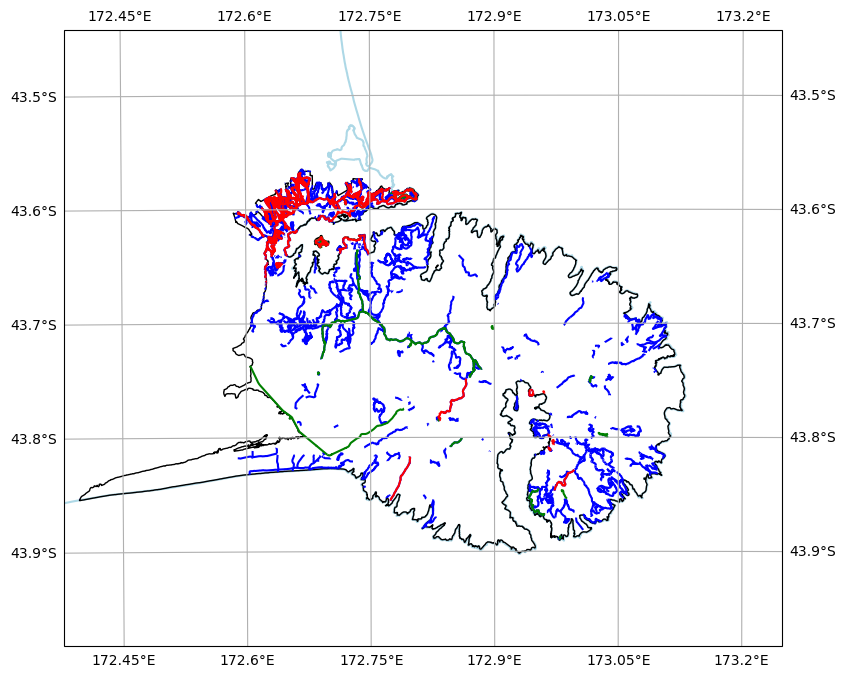

In [21]:
# Set up NZTM map canvas
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.epsg(2193))

# Load coastline context
coast = gpd.read_file("Data/Coast_Banks.gpkg")
coast = coast.to_crs(epsg=2193)
coast.plot(ax=ax, color="lightblue")

# Plot study area and route sources by manager
bp_mask.boundary.plot(ax=ax, edgecolor="black", linewidth=1)
all_routes_reduced[all_routes_reduced["Manager"] == "OSM"].plot(ax=ax, transform=ccrs.epsg(2193), color="blue", markersize=5)
all_routes_reduced[all_routes_reduced["Manager"] == "DOC"].plot(ax=ax, transform=ccrs.epsg(2193), color="green", markersize=5)
all_routes_reduced[all_routes_reduced["Manager"] == "CCC"].plot(ax=ax, transform=ccrs.epsg(2193), color="red", markersize=5)

# Zoom to Banks Peninsula extent
ax.set_extent([1550000, 1620000, 5130000, 5190000], crs=ccrs.epsg(2193))
ax.gridlines(draw_labels=True)

plt.show()

# Gradient of edges

In [9]:
edges = gpd.read_file(r"Data\Map_Matching\Graph_Filter_all\edges.shp", driver="GPKG")
dem = rio.open(r"Data\Supplementaries\nztm.tif")

c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver ESRI Shapefile does not support open option DRIVER
  return ogr_read(


In [14]:
# Compute a walkability grading metric from the DEM.
# The main column is elevation_effort_m, which is total ascent + total descent
# sampled along each edge geometry.

from math import isnan
from shapely.geometry import LineString, MultiLineString
from shapely.ops import linemerge


def _ensure_linestring(geometry):
    if geometry is None or geometry.is_empty:
        return None

    if geometry.geom_type == "LineString":
        return geometry

    if geometry.geom_type == "MultiLineString":
        merged = linemerge(geometry)
        if merged.geom_type == "LineString":
            return merged
        if merged.geom_type == "MultiLineString":
            return max(list(merged.geoms), key=lambda part: part.length, default=None)

    return None


def _sample_elevation_profile(geometry, raster, spacing_m=10):
    line = _ensure_linestring(geometry)
    if line is None or line.length == 0:
        return None

    distances = [0.0]
    current_distance = spacing_m
    while current_distance < line.length:
        distances.append(current_distance)
        current_distance += spacing_m
    if distances[-1] != line.length:
        distances.append(line.length)

    coordinates = [line.interpolate(distance).coords[0] for distance in distances]
    samples = [value[0] for value in raster.sample(coordinates)]

    valid_elevations = []
    for value in samples:
        if value is None:
            continue
        try:
            elevation = float(value)
        except (TypeError, ValueError):
            continue
        if raster.nodata is not None and elevation == raster.nodata:
            continue
        if isnan(elevation):
            continue
        valid_elevations.append(elevation)

    if len(valid_elevations) < 2:
        return None

    deltas = [current - previous for previous, current in zip(valid_elevations[:-1], valid_elevations[1:])]
    elevation_gain_m = sum(delta for delta in deltas if delta > 0)
    elevation_loss_m = sum(-delta for delta in deltas if delta < 0)
    elevation_effort_m = elevation_gain_m + elevation_loss_m
    net_elevation_change_m = valid_elevations[-1] - valid_elevations[0]
    grade_effort_pct = (elevation_effort_m / line.length) * 100 if line.length else None

    return {
        "sample_count": len(valid_elevations),
        "start_elevation_m": valid_elevations[0],
        "end_elevation_m": valid_elevations[-1],
        "net_elevation_change_m": net_elevation_change_m,
        "elevation_gain_m": elevation_gain_m,
        "elevation_loss_m": elevation_loss_m,
        "elevation_effort_m": elevation_effort_m,
        "grade_effort_pct": grade_effort_pct,
    }


if edges.crs != dem.crs:
    edges = edges.to_crs(dem.crs)


elevation_metrics = edges.geometry.apply(lambda geometry: _sample_elevation_profile(geometry, dem, spacing_m=10))
elevation_metrics_df = pd.json_normalize([metrics if metrics is not None else {} for metrics in elevation_metrics])
edges = pd.concat([edges.reset_index(drop=True), elevation_metrics_df], axis=1)

edges.to_file("Data/Map_Matching/Graph_Filter_all/edges_with_elevation.gpkg", driver="GPKG")
print(f"Saved {len(edges):,} edges with DEM-based elevation metrics")

Saved 16,007 edges with DEM-based elevation metrics
